In [1]:
%matplotlib inline
import mdtraj as md
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib
from contact_map import ContactFrequency, ContactDifference, AtomMismatchedContactDifference
import scipy.stats as st
from scipy.stats import ttest_ind
from tqdm.notebook import tqdm
import random

In [2]:
minA = 1
maxA = 58
minB = 60
maxB = 72
traj_combined_list = []

# No salt new encounter frames

In [3]:
traj_no_salt_list = [
    "/cluster_0_allsim.mdcrd",
    "/cluster_1_allsim.mdcrd",
    "/cluster_2_allsim.mdcrd",
    "/cluster_3_allsim.mdcrd",
    "/cluster_4_allsim.mdcrd",]

prmtop_list = [
    "/data/chem_shared/SH3/ArkA12-SH3_binding/ArkA12_1_gas.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding/ArkA12_1_gas.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding/ArkA12_1_gas.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding/ArkA12_1_gas.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding/ArkA12_1_gas.prmtop",
]

traj_no_salt_new = []
for traj_path, top_path in zip(traj_no_salt_list, prmtop_list):
    full_traj_path = "/data/mcohen3/SH3/no_salt_stripped_mdcrds" + traj_path
    traj_no_salt_new.append(
        md.load_netcdf(full_traj_path, top=top_path, stride=100) # the stride should be some multiple of 10
    )

In [4]:
no_salt_split_traj = []

# split trajectories into their independent simulations
for j in range(len(traj_no_salt_new)):
    n = int(traj_no_salt_new[j].n_frames/10)
    
    split_traj = [traj_no_salt_new[j][i:i + n] for i in range(0, len(traj_no_salt_new[j]), n)]
    no_salt_split_traj.append(split_traj)

In [5]:
no_salt_split_traj[0][0]

<mdtraj.Trajectory with 1000 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f13b8ef0>

In [6]:
traj_no_salt_new[1]

<mdtraj.Trajectory with 10000 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f15ac830>

In [7]:
arka12_stat = pd.read_csv('/data/mcohen3/SH3/no_salt_analysis/status_files_use_this/ArkA12_binding_no_salt_status.csv')
arka12_stat = arka12_stat.iloc[99::100, :]

In [8]:
# tot_frames = len(arka12_stat)
# num_clusters = 5
# traj_no_salt_encounter = []

# for i in range(num_clusters):
#     arka12_stat_cluster = arka12_stat[int(tot_frames*(i/num_clusters)):int(tot_frames*((i+1)/num_clusters))]
#     traj_no_salt_encounter.append(traj_no_salt_new[i][(arka12_stat_cluster['status'] != 'unbound') & (arka12_stat_cluster['status'] != 'Bound')])

In [9]:
# ChatGPT came up with this

num_clusters = 5
num_sims = 10

frames_per_sim = len(arka12_stat) // (num_clusters * num_sims)

traj_no_salt_encounter_ind = [] # for independent simulations

for i in range(num_clusters):
    for sim in range(num_sims):
        start = (i * num_sims + sim) * frames_per_sim
        stop = start + frames_per_sim

        arka12_stat_cluster_sim = arka12_stat.iloc[start:stop]

        mask = (
            (arka12_stat_cluster_sim['status'] != 'unbound') &
            (arka12_stat_cluster_sim['status'] != 'Bound')
        ).to_numpy()

        traj_no_salt_encounter_ind.append(no_salt_split_traj[i][sim][mask])

In [10]:
traj_no_salt_encounter_ind

[<mdtraj.Trajectory with 920 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f160bec0>,
 <mdtraj.Trajectory with 973 frames, 1098 atoms, 72 residues, without unitcells at 0x1553f17802f0>,
 <mdtraj.Trajectory with 845 frames, 1098 atoms, 72 residues, without unitcells at 0x1553c8df3f80>,
 <mdtraj.Trajectory with 865 frames, 1098 atoms, 72 residues, without unitcells at 0x1553c80b3890>,
 <mdtraj.Trajectory with 843 frames, 1098 atoms, 72 residues, without unitcells at 0x1553c7f395b0>,
 <mdtraj.Trajectory with 972 frames, 1098 atoms, 72 residues, without unitcells at 0x1553c7ddf290>,
 <mdtraj.Trajectory with 763 frames, 1098 atoms, 72 residues, without unitcells at 0x1553c7e70f50>,
 <mdtraj.Trajectory with 36 frames, 1098 atoms, 72 residues, without unitcells at 0x1553c7d22c60>,
 <mdtraj.Trajectory with 797 frames, 1098 atoms, 72 residues, without unitcells at 0x1553c7bbc9e0>,
 <mdtraj.Trajectory with 913 frames, 1098 atoms, 72 residues, without unitcells at 0x1553c7c566c0>,
 

In [11]:
no_salt_split_traj[i][sim]

<mdtraj.Trajectory with 1000 frames, 1098 atoms, 72 residues, without unitcells at 0x1553ca872450>

In [12]:
topology = md.join(traj_no_salt_new).topology
df = topology.to_dataframe()[0]
topology = md.Topology.from_dataframe(df[(df['element'] != 'Na')][(df['element'] != 'Cl')])

In [13]:
traj_no_salt_combined = md.join(traj_no_salt_encounter_ind)
#traj_no_salt_combined = md.join(traj_no_salt_encounter_ind)

In [14]:
traj_no_salt_combined_contacts = ContactFrequency(traj_no_salt_combined)

# AbpSH3 ArkA12 No salt Encounter

In [15]:
# traj_no_salt_list = ["encounter_complex_nosalt_sim1-stripped.mdcrd", "encounter_complex_nosalt_sim2-stripped.mdcrd", "encounter_complex_nosalt_sim3-stripped.mdcrd", "encounter_complex_nosalt_sim4-stripped.mdcrd", "encounter_complex_nosalt_sim5-stripped.mdcrd", "encounter_complex_nosalt_sim6-stripped.mdcrd", "encounter_complex_nosalt_sim7-stripped.mdcrd", "encounter_complex_nosalt_sim8-stripped.mdcrd", "encounter_complex_nosalt_sim9-stripped.mdcrd", "encounter_complex_nosalt_sim10-stripped.mdcrd"]

# traj_no_salt_new = []
# for suffix in traj_no_salt_list:
#     traj_no_salt_new.append(md.load_netcdf("/data/amujica/ArkA12_binding/nosalt_filtered/stripped/" + suffix, 
#                           top="/data/rcarrock/ArkA_binding_cont/analysis_all/ArkA12_1_gas.prmtop", 
#                                    stride=100))

In [16]:
# traj_no_salt_new[0]

In [17]:
# topology = traj_no_salt_new[0].topology
# topology

In [18]:
# traj_no_salt_new

In [19]:
# traj_no_salt_combined = md.join(traj_no_salt_new)

In [20]:
# traj_no_salt_combined_contacts = ContactFrequency(traj_no_salt_combined)

Current dimensions: 20.0 x 4.0 inches
New dimensions: 7 x 1.4000000000000001 inches


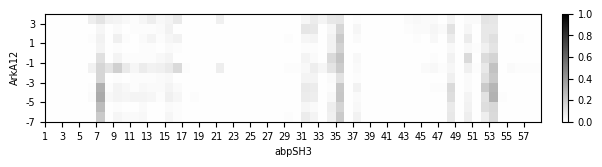

CPU times: user 2.34 s, sys: 12 ms, total: 2.35 s
Wall time: 2.36 s


In [21]:
%%time
cmap = matplotlib.colors.LinearSegmentedColormap.from_list("", ["black","white","black"])
fig, ax = traj_no_salt_combined_contacts.residue_contacts.plot (figsize=(20, 4), cmap=cmap)
cb_ax = fig.axes[1]
cb_ax.tick_params(labelsize=7)
my_xticks = []
current_xticks = []

for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)

# --- Y-Axis Relabeling ---
my_yticks = ['-7', '-5', '-3', '-1', '1', '3'] # THIS IS WRONG, labelling is flipped
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
current_yticks = np.linspace(60, 70, len(my_yticks))

ax.set_yticks(current_yticks)
ax.set_yticklabels(my_yticks, fontsize=7)
ax.set_ylim(60, 71)
ax.set_xlim(0,58)

# -------------------------
    
plt.xticks(current_xticks, my_xticks, fontsize = 7)
#ax.set_yticklabels(my_yticks)
plt.yticks(current_yticks, my_yticks, fontsize = 7)
plt.xlabel("abpSH3", fontsize=7)
plt.ylabel("ArkA12", fontsize=7)
#plt.title('ArkA12_bound_contact_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_phosphorylated.png', bbox_inches = "tight", dpi= 2000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('contact_no_salt.png', dpi=1000, bbox_inches='tight')

plt.show()

# AbpSH3 ArkA12 Salt Encounter 

In [22]:
traj_salt_list = [
    "/cluster_0/cluster_0_allsim.mdcrd",
    "/cluster_1/cluster_1_allsim.mdcrd",
    "/cluster_2/cluster_2_allsim.mdcrd",
    "/cluster_3/cluster_3_allsim.mdcrd",
    "/cluster_4/cluster_4_allsim.mdcrd",]

prmtop_list = [
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_0/ArkA12_0_gas_ions.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_1/ArkA12_1_gas_ions.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_2/ArkA12_2_gas_ions.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_3/ArkA12_3_gas_ions.prmtop",
    "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl/cluster_4/ArkA12_4_gas_ions.prmtop",
]

traj_salt_new = []
for traj_path, top_path in zip(traj_salt_list, prmtop_list):
    full_traj_path = "/data/chem_shared/SH3/ArkA12-SH3_binding_800mM_NaCl" + traj_path
    traj_salt_new.append(
        md.load_netcdf(full_traj_path, top=top_path, stride=100) # the stride should be some multiple of 10
    )


In [23]:
salt_split_traj = []

# split trajectories into their independent simulations
for j in range(len(traj_salt_new)):
    n = int(traj_salt_new[j].n_frames/num_sims)
    
    split_traj = [traj_salt_new[j][i:i + n] for i in range(0, len(traj_salt_new[j]), n)]
    salt_split_traj.append(split_traj)

In [24]:
salt_split_traj

[[<mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553b457c680>,
  <mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553b45b5820>,
  <mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553b4410350>,
  <mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553aff06e40>,
  <mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553b439a3f0>,
  <mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553afdd43e0>,
  <mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553afc8eea0>,
  <mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553afb519a0>,
  <mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553afa104a0>,
  <mdtraj.Trajectory with 1000 frames, 1475 atoms, 449 residues, without 

In [25]:
traj_salt_new

[<mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553b4990ef0>,
 <mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553b44e04d0>,
 <mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553c45e0170>,
 <mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553b4591bb0>,
 <mdtraj.Trajectory with 10000 frames, 1475 atoms, 449 residues, without unitcells at 0x1553b4242390>]

## Add code to use only encounter frames

In [26]:
arka12_stat = pd.read_csv('/data/jcardoso/binding_figures_800ArkA12/ArkA12/pair_wise_distances/binding/salt/status_files/ArkA12_binding_salt_status.csv')
arka12_stat = arka12_stat.iloc[99::100, :]

In [27]:
# tot_frames = len(arka12_stat)
# num_clusters = 5
# traj_salt_encounter = []

# for i in range(num_clusters):
#     arka12_stat_cluster = arka12_stat[int(tot_frames*(i/num_clusters)):int(tot_frames*((i+1)/num_clusters))]
#     traj_salt_encounter.append(traj_salt_new[i][(arka12_stat_cluster['status'] != 'unbound') & (arka12_stat_cluster['status'] != 'Bound')])

In [28]:
# ChatGPT came up with this

num_clusters = 5
num_sims = 10

frames_per_sim = len(arka12_stat) // (num_clusters * num_sims)

traj_salt_encounter_ind = [] # for independent simulations

for i in range(num_clusters):
    for sim in range(num_sims):
        start = (i * num_sims + sim) * frames_per_sim
        stop = start + frames_per_sim

        arka12_stat_cluster_sim = arka12_stat.iloc[start:stop]

        mask = (
            (arka12_stat_cluster_sim['status'] != 'unbound') &
            (arka12_stat_cluster_sim['status'] != 'Bound')
        ).to_numpy()

        traj_salt_encounter_ind.append(salt_split_traj[i][sim][mask])

In [29]:
for traj in range(len(traj_salt_encounter_ind)):
    traj_salt_encounter_ind[traj] = traj_salt_encounter_ind[traj].remove_solvent()

In [30]:
topology = md.join(traj_salt_new).topology
df = topology.to_dataframe()[0]
topology = md.Topology.from_dataframe(df[(df['element'] != 'Na')][(df['element'] != 'Cl')])

/tmp/ipykernel_2486490/7110114.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  topology = md.Topology.from_dataframe(df[(df['element'] != 'Na')][(df['element'] != 'Cl')])


In [31]:
traj_combined_salt = md.join(traj_salt_encounter_ind)

In [32]:
traj_combined_salt

<mdtraj.Trajectory with 31838 frames, 1098 atoms, 72 residues, without unitcells at 0x1553bb779f10>

In [33]:
#traj_combined_salt = traj_combined_salt.remove_solvent()

In [34]:
traj_combined_contacts_salt = ContactFrequency(traj_combined_salt)

Current dimensions: 20.0 x 4.0 inches
New dimensions: 7 x 1.4000000000000001 inches


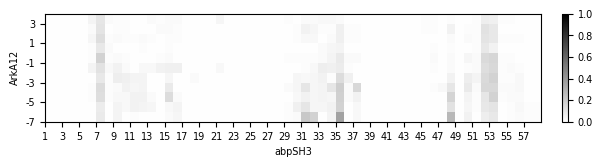

CPU times: user 2.2 s, sys: 18.9 ms, total: 2.22 s
Wall time: 2.22 s


In [35]:
%%time
fig, ax = traj_combined_contacts_salt.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap= cmap)
cb_ax = fig.axes[1]
cb_ax.tick_params(labelsize=7)

my_xticks = []
current_xticks = []

for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
# --- Y-Axis Relabeling ---
#my_yticks = ['-7', '-5', '-3', '-1', '1', '3']
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
#current_yticks = np.linspace(60, 70, len(my_yticks))

ax.set_yticks(current_yticks)
#ax.set_yticklabels(my_yticks, fontsize=7)
ax.set_ylim(60, 71)
ax.set_xlim(0,58)

# -------------------------
    
plt.xticks(current_xticks, my_xticks, fontsize = 7)
#ax.set_yticklabels(my_yticks)
plt.yticks(current_yticks, my_yticks, fontsize = 7)
plt.xlabel("abpSH3", fontsize=7)
plt.ylabel("ArkA12", fontsize=7)
#plt.title('ArkA12_bound_contact_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_phosphorylated.png', bbox_inches = "tight", dpi= 2000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('contact_salt.png', dpi=1000, bbox_inches='tight')

plt.show()

In [36]:
def get_window(diffy):
    window = pd.DataFrame(diffy.residue_contacts.df.iloc[:maxB-1, :maxB-1]).fillna(0).iloc[minB-1:maxB-1, minA-1:maxA]
    return window.reindex(index=window.index[::-1])

In [37]:
diffy_salt = []
diffy_no_salt = []
for i in tqdm(range(min(len(traj_salt_encounter_ind), len(traj_no_salt_encounter_ind)))):
    #diffy.append(AtomMismatchedContactDifference(salt_con, no_salt_con))
    diffy_salt.append(ContactFrequency(traj_salt_encounter_ind[i]))
    diffy_no_salt.append(ContactFrequency(traj_no_salt_encounter_ind[i]))

  0%|          | 0/50 [00:00<?, ?it/s]

In [38]:
def ci_intersect(bs1, bs2):
    high1 = bs1.confidence_interval.high
    high2 = bs1.confidence_interval.high
    low1 = bs2.confidence_interval.low
    low2 = bs2.confidence_interval.low
    
    if low1 < low2:
        return high1 < low2
    else:
        return high2 < low1

In [39]:
def bootstrap(data1, data2, numsample=int(1e5)):
    len_1 = len(data1)
    len_2 = len(data2)
    
    data = np.concatenate([data1, data2])

    diff = abs(np.mean(data[:len_2]) - np.mean(data[len_1:]))
    
    diff_samples = np.zeros(numsample)
    diff_samples_larger = 0

    for sample in range(len(diff_samples)):
        random_groups = np.random.permutation(data)
        
        diff_samples[sample] = np.mean(random_groups[:len_2]) - np.mean(random_groups[len_1:])
        
        if diff_samples[sample] >= diff:
            diff_samples_larger += 1

    return (1 + diff_samples_larger) / (numsample + 1)

In [40]:
import scipy.stats

diff_df_salt = [get_window(diff) for diff in diffy_salt]
diff_df_no_salt = [get_window(diff) for diff in diffy_no_salt]
significant = diff_df_salt[0].copy().sparse.to_dense()

# p_val_df = diff_df_no_salt[0].copy(deep=True)
p_val_df = pd.DataFrame().reindex_like(diff_df_no_salt[0])

for col in tqdm(range(len(diff_df_salt[0].columns))):
    for row in range(len(diff_df_salt[0].index)):
        salt_data = [df.iloc[row, col] for df in diff_df_salt]
#         print(f"salty daty: ",row, col)
        no_salt_data = [df.iloc[row, col] for df in diff_df_no_salt]
        if all(v == 0 for v in no_salt_data) and all(v == 0 for v in salt_data):
            significant.iloc[row, col] = 1
        else:
            pval = bootstrap(salt_data, no_salt_data)
            significant.iloc[row, col] = pval
# p_val_df

  0%|          | 0/58 [00:00<?, ?it/s]

In [41]:
significant

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
70,0.500695,0.499225,1.000000,0.120999,0.082379,0.110239,0.473475,0.101069,0.003480,0.012550,...,1.000000,0.033450,0.130509,0.315637,0.217078,0.092599,0.265857,0.227068,0.156828,0.422406
69,0.372616,0.300757,1.000000,0.374926,0.497015,0.044990,0.006100,0.031430,0.087219,0.309737,...,0.248728,0.039610,0.019160,0.166418,0.383936,0.154698,0.045740,0.097119,0.237948,0.467975
68,0.254627,0.436326,1.000000,0.246048,1.000000,0.101719,0.017210,0.306487,0.057399,0.324677,...,0.500545,0.049670,0.089559,0.286677,0.238458,0.006620,0.469105,0.355826,0.292167,0.362876
67,0.247058,0.498665,0.500305,0.374286,1.000000,0.005990,0.035740,0.004080,0.216268,0.061269,...,1.000000,0.075049,0.469985,0.155938,0.076759,0.001100,0.254297,0.425606,0.131939,0.396196
66,0.247308,0.308247,1.000000,0.501585,1.000000,0.114099,0.186128,0.368836,0.153498,0.491115,...,0.497875,0.014290,0.081909,0.383606,0.473955,0.012580,0.141779,0.061099,0.312587,0.246908
65,0.120679,0.500945,1.000000,0.312057,0.248778,0.302537,0.196598,0.010490,0.007560,0.000050,...,1.000000,0.010700,0.276957,0.159088,0.109899,0.445056,0.415596,0.435676,0.309927,0.308267
64,0.057599,0.501615,1.000000,0.499245,1.000000,0.293797,0.075029,0.009880,0.048160,0.006820,...,1.000000,0.261467,0.019820,0.366126,0.170308,0.241508,0.189248,0.002650,0.150988,0.370906
63,0.012870,0.373756,1.000000,0.247088,0.249708,0.447906,0.009430,0.390706,0.166388,0.439006,...,0.290297,0.019880,0.013190,0.236278,0.016550,0.037480,0.119229,0.000420,0.034140,0.095579
62,0.247938,0.498855,1.000000,0.503105,0.122249,0.186548,0.001980,0.011620,0.323667,0.161228,...,0.499235,0.180618,0.114649,0.277177,0.038060,0.426306,0.370846,0.000500,0.027610,0.012310
61,0.004380,0.059229,1.000000,0.500185,1.000000,0.167128,0.000360,0.353426,0.024110,0.015350,...,0.247948,0.273337,0.211368,0.160608,0.116879,0.269797,0.186268,0.000070,0.011330,0.001450


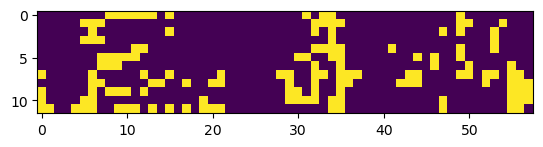

In [42]:
plt.imshow(np.array((significant < 0.05).values.tolist()))

# ArkA12_Encounter_Contact_Difference

In [43]:
diff = AtomMismatchedContactDifference(traj_no_salt_combined_contacts, traj_combined_contacts_salt)

Current dimensions: 20.0 x 4.0 inches
New dimensions: 7 x 1.4000000000000001 inches


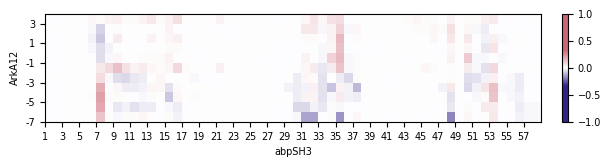

CPU times: user 2.33 s, sys: 22.9 ms, total: 2.35 s
Wall time: 2.36 s


In [44]:
%%time
map_1 = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#332288","#332288","#332288","white","#CC6677","#CC6677","#CC6677"])
fig, ax = diff.residue_contacts.plot(nrows=1, ncols=1, figsize=(20, 4), cmap = map_1)
cb_ax = fig.axes[1]
cb_ax.tick_params(labelsize=7)
#plt.imshow(np.array((significant < 0.05).values.tolist()))
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []


for x in range(int(minA), int(maxA)+1, 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
# --- Y-Axis Relabeling ---
#my_yticks = ['-7', '-5', '-3', '-1', '1', '3']
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
#current_yticks = np.linspace(60, 70, len(my_yticks))

#ax.set_yticks(current_yticks)
#ax.set_yticklabels(my_yticks, fontsize=7)
ax.set_ylim(60, 71)
ax.set_xlim(0,58)

# -------------------------
    
plt.xticks(current_xticks, my_xticks, fontsize = 7)
#ax.set_yticklabels(my_yticks)
plt.yticks(current_yticks, my_yticks, fontsize = 7)
plt.xlabel("abpSH3", fontsize=7)
plt.ylabel("ArkA12", fontsize=7)
#plt.title('ArkA12_bound_contact_map', fontsize=18)
# fig.savefig('/home/oonwuzul/data/ctd_Figures_for_Lia_2023/ctd_combined/plots/ctd_phosphorylated.png', bbox_inches = "tight", dpi= 2000)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('contact_diff.png', dpi=1000, bbox_inches='tight')

plt.show()

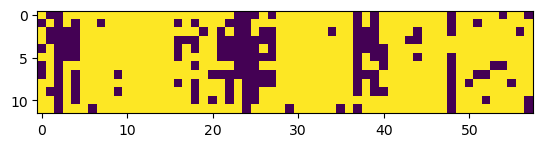

In [45]:
#np.array((significant[significant < 0.05]).values.tolist())
#ax.set_ylim(60, 71)
#ax.set_xlim(0,58)
salt = traj_combined_contacts_salt.residue_contacts.df.iloc[minB-1:maxB-1,minA-1:maxA]
no_salt = traj_no_salt_combined_contacts.residue_contacts.df.iloc[minB-1:maxB-1,minA-1:maxA]
difference = diff.residue_contacts.df.iloc[minB-1:maxB-1,minA-1:maxA]

perc_diff = ((difference.abs())/((salt + no_salt)/2))*100
plt.imshow(np.array((perc_diff > 10).values.tolist()))

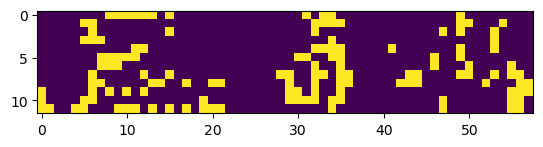

In [46]:
plt.imshow(np.array((significant < 0.05).values.tolist()) & np.array((perc_diff > 10).values.tolist()))

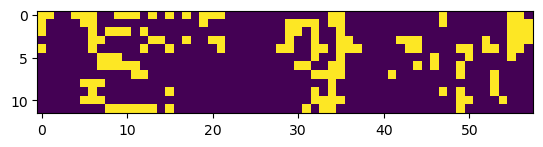

In [47]:
# Flip rows of significant dataframe to match with correct rows of diff dataframe
significant_rev = significant.iloc[::-1]
plt.imshow(np.array((significant_rev < 0.05).values.tolist()))

Current dimensions: 6.4 x 4.8 inches
New dimensions: 7 x 5.249999999999999 inches


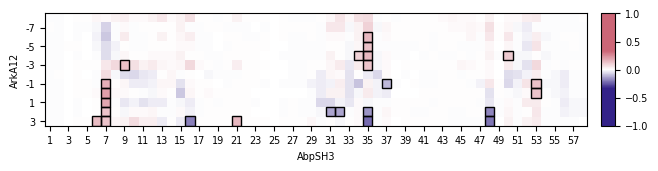

In [48]:
num_values = len(significant_rev) * len(significant_rev.columns) # following the Bonferroni Method
#sig_and_10 = np.array((significant_rev < (0.05/num_values)).values.tolist()) & np.array((abs(difference) > 0.1).values.tolist())
#sig_and_10 = np.array((significant < (0.05/num_values)).values.tolist())
sig_and_10 = np.array((significant_rev < (0.05)).values.tolist()) & np.array((abs(difference) > 0.1).values.tolist())
coords = np.argwhere(sig_and_10)

map_1 = matplotlib.colors.LinearSegmentedColormap.from_list("", ["#332288","#332288","#332288","white","#CC6677","#CC6677","#CC6677"])
#fig, ax = difference.residue_contacts.plot(cmap = map_1)

fig, ax = plt.subplots()
im = plt.imshow(difference, cmap = map_1, vmin = -1, vmax = 1)
# 1. Get the current position of the plot in the figure
pos = ax.get_position()

# --- MISSING PIECE START ---
# Define the colorbar axes [left, bottom, width, height]
# pos.x1 + 0.02 puts it just to the right of the plot
# pos.y0 and pos.height ensure the vertical size matches exactly
cax = fig.add_axes([pos.x1 + 0.02, pos.y0, 0.02, pos.height])
# --- MISSING PIECE END ---

# Now this will work
cb = fig.colorbar(im, cax=cax)
cax.tick_params(labelsize=7)

# 2. Extract coordinates where mask is True
# Note: np.argwhere returns (row, col), but patches use (x, y) which is (col, row)

for row, col in coords:
    # Create a Rectangle patch
    # (col - 0.5, row - 0.5) aligns the box edges with the pixel edges
    rect = patches.Rectangle((col - 0.5, row - 0.5), 1, 1, 
                             linewidth=1, edgecolor='black', facecolor='none')
    ax.add_patch(rect)

#cb_ax = fig.axes[0]
#cb_ax.tick_params(labelsize=7)
#plt.imshow(np.array((significant < 0.05).values.tolist()))
#PRGn is a matplot lib diverging colormap, using _r appendix on it to reverse if needed
my_xticks = []
current_xticks = []


for x in range(int(minA)-1, int(maxA), 2):
    current_xticks.append(x-int(minA))
    my_xticks.append(x)
    
# --- Y-Axis Relabeling ---
#my_yticks = ['-7', '-5', '-3', '-1', '1', '3']
my_yticks = ['3', '1', '-1', '-3', '-5', '-7'] # correct labelling
# This creates positions [60. , 62. , 64. , 66. , 68. , 70.]
current_yticks = np.arange(0, 12, 2)

ax.set_xlabel("AbpSH3", fontsize = 7)
ax.set_ylabel("ArkA12", fontsize = 7)

my_xticks = []
current_xticks = []

# Loop through every single number in the range
for x in range(int(minA), int(maxA) + 1):
    # Check if the residue number is odd
    if x % 2 != 0:
        current_xticks.append(x - int(minA)) # The pixel position
        my_xticks.append(x)                  # The actual label

# Apply to the plot
ax.set_xticks(current_xticks)
ax.set_xticklabels(my_xticks, fontsize=7)
ax.set_yticks(current_yticks)
ax.set_yticklabels(my_yticks, fontsize=7)
ax.invert_yaxis()
#ax.set_ylim(60, 71)
#ax.set_xlim(0,58)

# Get the current figure
fig = plt.gcf()

# Get the current dimensions
current_width, current_height = fig.get_size_inches()
print(f"Current dimensions: {current_width} x {current_height} inches")

# Define the new width
new_width = 7 # inches

# Calculate the new height to maintain the aspect ratio
aspect_ratio = current_height / current_width
new_height = new_width * aspect_ratio
print(f"New dimensions: {new_width} x {new_height} inches")

# Set the new figure size
fig.set_size_inches(new_width, new_height)

# Save the figure
plt.savefig('contact_diff.png', dpi=1000, bbox_inches='tight')

plt.show()

## Randomization test

In [49]:
test_stat = np.nansum((difference**2).to_numpy())

In [50]:
# Pool together simulations from each set into one list

traj_all_ind = traj_no_salt_encounter_ind + traj_salt_encounter_ind

for traj in range(len(traj_all_ind)):
    traj_all_ind[traj] = traj_all_ind[traj].remove_solvent()

# Randomly select half of these sims for the first category (eg. no salt) and the other half in the second category (eg. salt)

# DO THIS 10,000 TIMES

random.seed(42)
tot_sims = int(len(traj_all_ind)/2)
random_groups = random.sample(traj_all_ind, len(traj_all_ind))
random_1 = random_groups[0:tot_sims] # "no salt"
random_2 = random_groups[tot_sims:tot_sims + tot_sims] # "salt"

In [51]:
traj_salt_encounter_ind

[<mdtraj.Trajectory with 481 frames, 1098 atoms, 72 residues, without unitcells at 0x1553b46a86b0>,
 <mdtraj.Trajectory with 238 frames, 1098 atoms, 72 residues, without unitcells at 0x1553c8df2f00>,
 <mdtraj.Trajectory with 664 frames, 1098 atoms, 72 residues, without unitcells at 0x1553bac6c1d0>,
 <mdtraj.Trajectory with 867 frames, 1098 atoms, 72 residues, without unitcells at 0x1553baafde80>,
 <mdtraj.Trajectory with 908 frames, 1098 atoms, 72 residues, without unitcells at 0x1553bab97b30>,
 <mdtraj.Trajectory with 748 frames, 1098 atoms, 72 residues, without unitcells at 0x1553baa3d820>,
 <mdtraj.Trajectory with 715 frames, 1098 atoms, 72 residues, without unitcells at 0x1553ba8d34d0>,
 <mdtraj.Trajectory with 702 frames, 1098 atoms, 72 residues, without unitcells at 0x1553ba9751c0>,
 <mdtraj.Trajectory with 602 frames, 1098 atoms, 72 residues, without unitcells at 0x1553ba812e70>,
 <mdtraj.Trajectory with 147 frames, 1098 atoms, 72 residues, without unitcells at 0x1553ba8b0b60>,


In [52]:
random_1_combined

NameError: name 'random_1_combined' is not defined

In [104]:
random_1_combined = md.join(random_1)
random_1_combined_contacts = ContactFrequency(random_1_combined)

In [105]:
random_1_combined_contacts.residue_contacts.df

,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
0,NaN,NaN,NaN,0.000027,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000027,0.00049,0.000191,0.000082,0.000218,0.000082,0.00049,0.000518,0.000245,0.000109
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,0.000109,0.000218,0.002943,0.00218,0.002834,0.000572,0.000245,0.000272,0.000054
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000054,NaN,NaN,NaN,NaN
3,0.000027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000245,0.000136,0.000082,0.008828,0.000163,0.000409,0.000572,0.000218,0.000817,0.000245
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000191,0.000054,NaN,0.000027,NaN,NaN,NaN,0.000027,0.000272,0.000599
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,0.000082,0.002834,0.000054,0.000409,NaN,0.00722,0.077814,0.014358,0.006784,0.002997,...,NaN,0.019045,0.029316,NaN,NaN,NaN,NaN,NaN,0.497589,0.12909
68,0.00049,0.000572,NaN,0.000572,NaN,0.020107,0.096368,0.008937,0.041087,0.009563,...,0.004359,0.016402,0.046781,0.080784,NaN,NaN,NaN,NaN,NaN,0.176689
69,0.000518,0.000245,NaN,0.000218,0.000027,0.013405,0.073809,0.006566,0.013105,0.008092,...,0.001444,0.006403,0.075988,0.235839,0.379424,NaN,NaN,NaN,NaN,NaN
70,0.000245,0.000272,NaN,0.000817,0.000272,0.065199,0.128028,0.038771,0.033322,0.021034,...,0.004005,0.018636,0.052829,0.182056,0.260932,0.497589,NaN,NaN,NaN,NaN


In [106]:
random_2_combined = md.join(random_2)
random_2_combined_contacts = ContactFrequency(random_2_combined)

In [107]:
diff_random = AtomMismatchedContactDifference(random_1_combined_contacts, random_2_combined_contacts)

In [ ]:
#test_stat = np.nansum((difference**2).to_numpy())

In [109]:
diff_random.residue_contacts.df

,0,1,2,3,4,5,6,7,8,9,...,62,63,64,65,66,67,68,69,70,71
0,NaN,NaN,NaN,0.000027,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.000304,-0.000111,-0.00017,-0.000099,0.000158,-0.001693,-0.000532,0.000157,0.000065,0.000049
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.00006,-0.000041,0.000068,0.002732,0.002059,0.002593,0.000241,-0.000116,0.000272,0.000054
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.000054,NaN,NaN,NaN,NaN
3,0.000027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000245,0.000106,0.000082,0.007294,0.000103,0.000409,0.000512,-0.000143,0.000186,0.000245
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.00008,0.000024,NaN,-0.000514,NaN,NaN,NaN,0.000027,-0.000179,0.000509
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,-0.001693,0.002593,0.000054,0.000409,NaN,0.003401,0.03177,0.008404,-0.006629,-0.002898,...,-0.00015,0.008098,0.015091,NaN,NaN,NaN,NaN,NaN,-0.038816,-0.009071
68,-0.000532,0.000241,NaN,0.000512,NaN,-0.004884,0.027799,0.006531,0.00184,-0.00391,...,0.002344,0.006929,-0.006661,-0.034611,NaN,NaN,NaN,NaN,NaN,0.005175
69,0.000157,-0.000116,NaN,-0.000143,0.000027,0.004834,0.016367,0.004431,-0.007105,-0.001051,...,-0.000721,-0.002319,-0.003047,-0.143398,-0.18486,NaN,NaN,NaN,NaN,NaN
70,0.000065,0.000272,NaN,0.000186,-0.000179,0.021561,0.051549,0.005328,0.00445,-0.002334,...,0.00175,0.007298,-0.014387,-0.109213,-0.079659,-0.038816,NaN,NaN,NaN,NaN


In [110]:
diff_new = diff_random.residue_contacts.df.iloc[minB-1:maxB-1,minA-1:maxA]

In [111]:
diff_new

,0,1,2,3,4,5,6,7,8,9,...,48,49,50,51,52,53,54,55,56,57
59,-0.000263,0.000038,NaN,0.000135,0.000124,-0.029993,-0.018154,0.001954,-0.049529,-0.050698,...,NaN,-0.042484,-0.001967,-0.046799,-0.092876,-0.003812,-0.002307,0.000658,-0.000831,NaN
60,0.000402,-0.000849,NaN,-0.000928,NaN,-0.002183,0.014202,0.001437,-0.032482,-0.011322,...,0.001258,-0.034116,-0.002061,-0.0186,-0.106569,0.000384,-0.003645,-0.006163,-0.002307,-0.00262
61,-0.00043,-0.000045,NaN,-0.000511,NaN,-0.007695,-0.040215,-0.000092,0.007211,0.000405,...,0.000599,-0.021843,0.008896,-0.025603,0.003736,-0.002676,-0.004907,-0.003637,-0.001514,-0.001664
62,-0.000304,-0.00006,NaN,0.000245,-0.00008,0.015386,-0.030871,-0.006833,0.009738,0.023944,...,-0.000211,0.031168,0.007878,0.063116,0.025693,0.014042,0.004788,-0.004414,-0.000449,0.000107
63,-0.000111,-0.000041,NaN,0.000106,0.000024,0.000061,-0.027391,0.012438,0.032517,0.02727,...,-0.001474,0.001743,-0.003609,0.018162,0.077131,-0.003015,0.003625,0.009346,-0.000139,-0.000009
64,-0.00017,0.000068,NaN,0.000082,NaN,0.001168,-0.01401,0.007689,0.006178,0.023243,...,NaN,-0.002837,0.007902,0.03703,0.047834,-0.004959,0.002481,0.010666,0.00215,0.003188
65,-0.000099,0.002732,NaN,0.007294,-0.000514,0.012125,0.039846,-0.001909,0.024284,0.015582,...,NaN,0.023186,0.002804,0.082302,0.024382,0.007909,0.025732,0.018532,0.01484,0.017197
66,0.000158,0.002059,NaN,0.000103,NaN,0.001179,0.033729,0.014676,0.013295,0.020797,...,0.000218,-0.000919,0.013457,0.023281,0.027401,0.006956,0.006635,0.001994,0.001111,0.005536
67,-0.001693,0.002593,0.000054,0.000409,NaN,0.003401,0.03177,0.008404,-0.006629,-0.002898,...,NaN,0.004815,0.018065,0.016283,0.009517,-0.000951,0.005573,0.002221,0.002819,0.007691
68,-0.000532,0.000241,NaN,0.000512,NaN,-0.004884,0.027799,0.006531,0.00184,-0.00391,...,0.000027,0.016849,0.004483,0.023338,0.020907,-0.000466,0.010266,0.014397,0.001123,0.004252


In [112]:
random_stat = np.nansum((diff_new**2).to_numpy())

In [113]:
random_stat

0.31539576706562344

In [114]:
test_stat

0.8287184804054906

In [122]:
avg_salt_contacts_list = []
for traj in range(len(traj_salt_encounter_ind)):
    ind_df = ContactFrequency(traj_salt_encounter_ind[traj]).residue_contacts.df.iloc[minB-1:maxB-1,minA-1:maxA]
    avg_salt_contacts = ind_df.sum().sum()
    avg_salt_contacts_list.append(avg_salt_contacts)

In [123]:
avg_contacts_list

[16.139293139293137,
 18.542016806722685,
 12.65210843373494,
 11.816608996539793,
 18.269823788546255,
 12.161764705882353,
 14.455944055944057,
 20.945868945868945,
 14.382059800664456,
 9.231292517006803,
 8.839285714285715,
 14.790301441677588,
 14.519572953736656,
 17.215686274509803,
 11.418872266973533,
 10.378881987577639,
 14.342857142857142,
 11.275534441805226,
 17.43421052631579,
 11.97632311977716,
 11.684210526315791,
 16.122609673790777,
 16.704866562009418,
 14.15126050420168,
 13.939922480620156,
 13.049937578027466,
 15.20121951219512,
 12.116751269035532,
 12.02469135802469,
 13.23982558139535,
 11.624349635796047,
 15.538567493112946,
 13.36556603773585,
 12.123595505617978,
 15.754716981132075,
 14.482869379014991,
 13.636163175303196,
 17.78413654618474,
 15.0,
 14.046332046332045,
 12.66079295154185,
 18.112266112266113,
 8.942857142857141,
 15.860800000000001,
 12.87443438914027,
 11.010600706713781,
 19.465116279069765,
 16.33534743202417,
 12.339928057553957,


In [124]:
avg_no_salt_contacts_list = []
for traj in range(len(traj_no_salt_encounter_ind)):
    ind_df = ContactFrequency(traj_no_salt_encounter_ind[traj]).residue_contacts.df.iloc[minB-1:maxB-1,minA-1:maxA]
    avg_no_salt_contacts = ind_df.sum().sum()
    avg_no_salt_contacts_list.append(avg_no_salt_contacts)

In [127]:
np.array(avg_no_salt_contacts_list).mean()

15.891715077566078

In [130]:
st.sem(np.array(avg_no_salt_contacts_list))

0.4378792094238784

In [128]:
np.array(avg_contacts_list).mean()

14.060477546687148

In [131]:
st.sem(np.array(avg_contacts_list))

0.3837801916103125

In [132]:
# Combine avg contact data (TOTAL)
avg_contact_values = np.concatenate([avg_no_salt_contacts_list, avg_salt_contacts_list])

nsim = 50

#calculate the real difference, no salt minus salt
diff_total = np.array(avg_no_salt_contacts_list).mean() - np.array(avg_salt_contacts_list).mean()

print("Avg # total contacts no-salt minus salt difference = " , diff_total)

#sample 10000 times and calculate differences
numsample = 10000
diff_samples = [0]*numsample
diff_samples_larger = [0]*numsample
for sample in range(0,len(diff_samples)):
    random_groups = np.random.permutation(avg_contact_values)
    diff_samples[sample] = (np.mean(random_groups[0:nsim]) 
             - np.mean(random_groups[nsim:nsim + nsim]))
    if diff_samples[sample] >= diff_total:
        diff_samples_larger[sample] = 1

#calculate p-value
pval_diff = (1 + np.sum(diff_samples_larger))/(numsample + 1)
print("p-value = " , pval_diff)

Avg # total contacts no-salt minus salt difference =  1.83123753087893
p-value =  0.001999800019998


In [53]:
tot_sims = int(len(traj_all_ind)/2)
random_stat_list = []
print(random_stat_list)

sample_size = 1
for sample in range(sample_size):
    if sample % 10 == 0:
        print(sample)
    random_groups = random.sample(traj_all_ind, len(traj_all_ind))
    random_1 = random_groups[0:tot_sims] # "no salt"
    random_2 = random_groups[tot_sims:tot_sims + tot_sims] # "salt"
    
    random_1_combined = md.join(random_1)
    print('getting contact frequency random_1')
    random_1_combined_contacts = ContactFrequency(random_1_combined)
    
    random_2_combined = md.join(random_2)
    print('getting contact frequency random_2')
    random_2_combined_contacts = ContactFrequency(random_2_combined)
    
    diff_random = AtomMismatchedContactDifference(random_1_combined_contacts, random_2_combined_contacts)
    diff_new = diff_random.residue_contacts.df.iloc[minB-1:maxB-1,minA-1:maxA]
    
    random_stat = np.nansum((diff_new**2).to_numpy())
    random_stat_list.append(random_stat)

pval = sum(1 for x in random_stat_list if x > test_stat)/sample_size
print("p-value = ", pval)

[]
0
getting contact frequency random_1
getting contact frequency random_2
p-value =  0.0


In [54]:
# --- STEP 1: Pre-calculate outside the loop ---
# Compute contact matrices for individual trajectories once
precomputed_contacts = []
for traj in traj_all_ind:
    # Get dataframe/matrix for individual trajectory
    contacts_df = ContactFrequency(traj).residue_contacts.df.iloc[minB-1:maxB-1, minA-1:maxA]
    precomputed_contacts.append(contacts_df.to_numpy())

# Convert to a single 3D NumPy array: shape -> (num_trajectories, rows, cols)
contacts_array = np.array(precomputed_contacts)

# --- STEP 2: Fast Permutation Loop ---
random_stat_list = []
sample_size = 1  # Example realistic sample size

for sample in range(sample_size):
    # Fast shuffle of indices instead of full objects
    shuffled_indices = np.random.permutation(len(traj_all_ind))
    
    group1_idx = shuffled_indices[:tot_sims]
    group2_idx = shuffled_indices[tot_sims : 2 * tot_sims]
    
    # Average precomputed matrices directly using NumPy
    avg_1 = np.nanmean(contacts_array[group1_idx], axis=0)
    avg_2 = np.nanmean(contacts_array[group2_idx], axis=0)
    
    # Calculate difference squared sum
    diff = avg_1 - avg_2
    random_stat = np.nansum(diff ** 2)
    random_stat_list.append(random_stat)

# --- STEP 3: Vectorized P-value ---
pval = sum(1 for x in random_stat_list if x > test_stat)/sample_size
print(f"p-value = {pval}")

KeyboardInterrupt: 

In [57]:
traj_0_0 = ContactFrequency(traj_all_ind[0][0]).residue_contacts.df.iloc[minB-1:maxB-1, minA-1:maxA]
traj_0_1 = ContactFrequency(traj_all_ind[0][1]).residue_contacts.df.iloc[minB-1:maxB-1, minA-1:maxA]

In [58]:
precomputed_contacts = []
precomputed_contacts.append(traj_0_0.to_numpy())
precomputed_contacts.append(traj_0_1.to_numpy())

In [60]:
np.shape(precomputed_contacts)

(2, 12, 58)

In [64]:
type(precomputed_contacts)

list

In [61]:
contacts_array = np.array(precomputed_contacts)

In [63]:
np.shape(contacts_array)

(2, 12, 58)

In [68]:
shuf_ind = np.random.permutation(2)
np.shape(contacts_array[shuf_ind])

(2, 12, 58)

In [70]:
np.shape(np.nanmean(contacts_array[shuf_ind], axis=0))

/tmp/ipykernel_2486490/562590254.py:1: RuntimeWarning: Mean of empty slice
  np.shape(np.nanmean(contacts_array[shuf_ind], axis=0))


(12, 58)

In [65]:
diff

array([[ 5.61980457e-03,             nan,             nan,
        -1.63805374e-04,  1.10075288e-03,  4.72623267e-02,
         6.44346954e-02,  1.66399420e-02, -6.64971484e-02,
        -5.67868596e-02, -9.78332576e-03, -6.40386005e-03,
         6.56807592e-02,  1.08980101e-02,  3.79689234e-02,
         1.80881027e-01,  2.90807367e-03, -7.48765645e-04,
        -2.68780109e-03, -2.09528796e-02,  1.70054081e-02,
         7.53333474e-03,  7.29673738e-03,             nan,
                    nan,  1.52540724e-04, -7.41302082e-03,
        -2.23665979e-03, -6.15845151e-02, -4.23471149e-03,
        -1.05003660e-02,  3.17312122e-03, -1.70792000e-03,
        -2.80338569e-02,  8.40536595e-02, -9.26846080e-03,
        -6.25927121e-02,             nan,  5.02804751e-03,
         6.89037234e-03, -3.38419598e-03, -8.87900755e-03,
         2.64489167e-03,  3.04057448e-03,  1.15094136e-02,
         2.39585131e-03, -2.45387842e-03,  1.42367629e-01,
                    nan, -1.05307356e-01, -9.73548813e-0

In [63]:
random_stat_list

[1.720440207322444,
 1.1565163970049008,
 1.2426707136066106,
 1.4312899169924327,
 2.2145500970014003,
 1.5060615521576084,
 1.0179791605313437,
 1.6400643453377557,
 1.8235772397816112,
 1.252655291485794]

In [64]:
test_stat

0.8287184804054906

In [58]:
contacts_array

array([[[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [   